<a href="https://colab.research.google.com/github/RonGopal/intro_to_AI/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
!pip install gradio

In [156]:
# import libraires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [142]:
# Loading csv
df = pd.read_csv("Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [143]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [144]:
# describe
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [145]:
# checking for null
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [146]:
# Cleaning up missing values
# Fill categorical columns with 'Unknown' by reassigning
df['Time_of_Day'] = df['Time_of_Day'].fillna('Unknown')
df['Weather'] = df['Weather'].fillna('Unknown')
df['Traffic_Level'] = df['Traffic_Level'].fillna('Unknown')

# Fill numerical column 'Courier_Experience_yrs' with its median by reassigning
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [147]:
df.isna().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [148]:
num_cols = df.select_dtypes(include=['float64','int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Replace missing categorical values with mode
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [149]:
# Convert categorical columns into one-hot encoded numeric columns
df_encoded = pd.get_dummies(df, drop_first=True)

In [150]:
#Separate features (X) and target variable (y)
X = df_encoded.drop("Delivery_Time_min", axis=1)
y = df_encoded["Delivery_Time_min"]

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [124]:
# Initialize linear regression model
#lr = LinearRegression()

# Train the model
#lr.fit(X_train, y_train)

# Predict on test set
#lr_pred = lr.predict(X_test)

In [123]:
# Evaluate baseline model
#print("MAE:", mean_absolute_error(y_test, lr_pred))
#print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

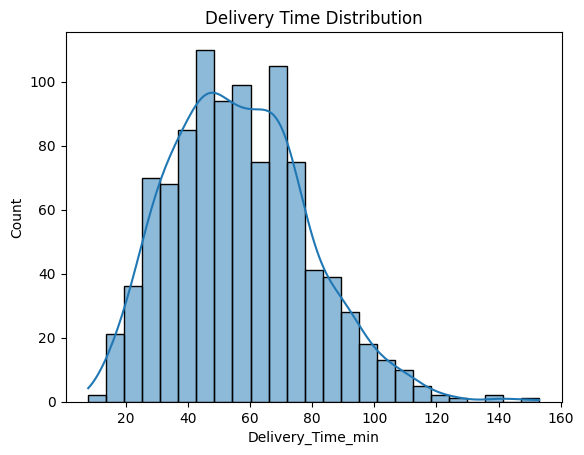

In [151]:
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

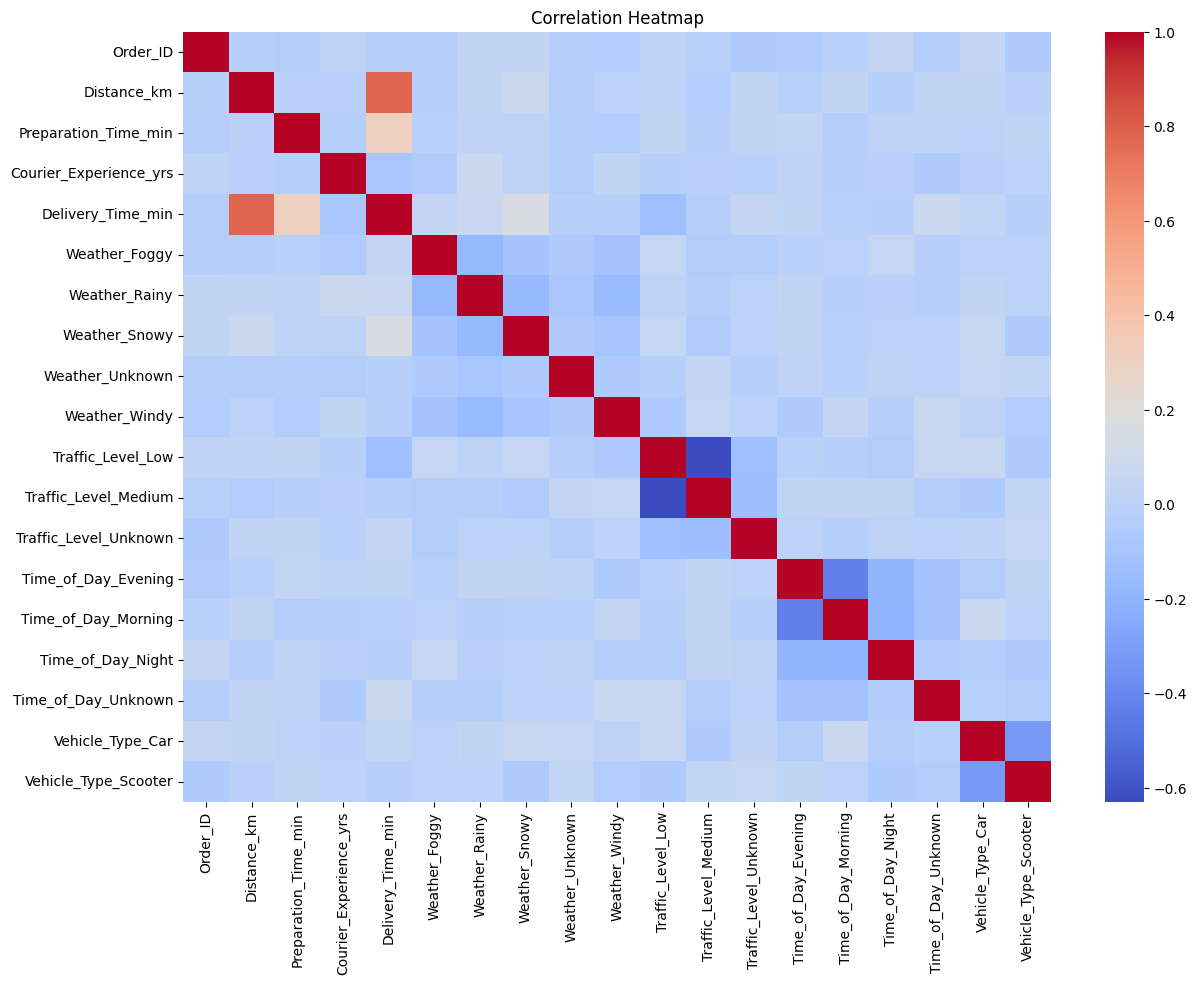

In [152]:
plt.figure(figsize=(14,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [158]:
# Initialize Random Forest model with reasonable defaults
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [159]:
# Predict on test set
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(7.397466666666666, np.float64(10.758352729133046), 0.7417778047730295)

In [163]:
# Evaluate Random Forest
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 7.397466666666666
RMSE: 10.758352729133046
R2: 0.7417778047730295


In [164]:
# Define hyperparameter grid to search
params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

# Grid search with 3-fold cross-validation
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Fit grid search
grid.fit(X_train, y_train)

# Retrieve best model
best_model = grid.best_estimator_

# Predict using best model
best_pred = best_model.predict(X_test)

In [165]:
# Evaluate tuned model
print("Tuned RF MAE:", mean_absolute_error(y_test, best_pred))
print("Tuned RF RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))

Tuned RF MAE: 7.316546156639208
Tuned RF RMSE: 10.732109743514131


Distance_km               0.672189
Preparation_Time_min      0.143456
Order_ID                  0.059577
Courier_Experience_yrs    0.031771
Traffic_Level_Low         0.016860
Weather_Snowy             0.010259
Time_of_Day_Unknown       0.008785
Time_of_Day_Evening       0.007743
Weather_Rainy             0.007252
Weather_Foggy             0.006543
dtype: float64


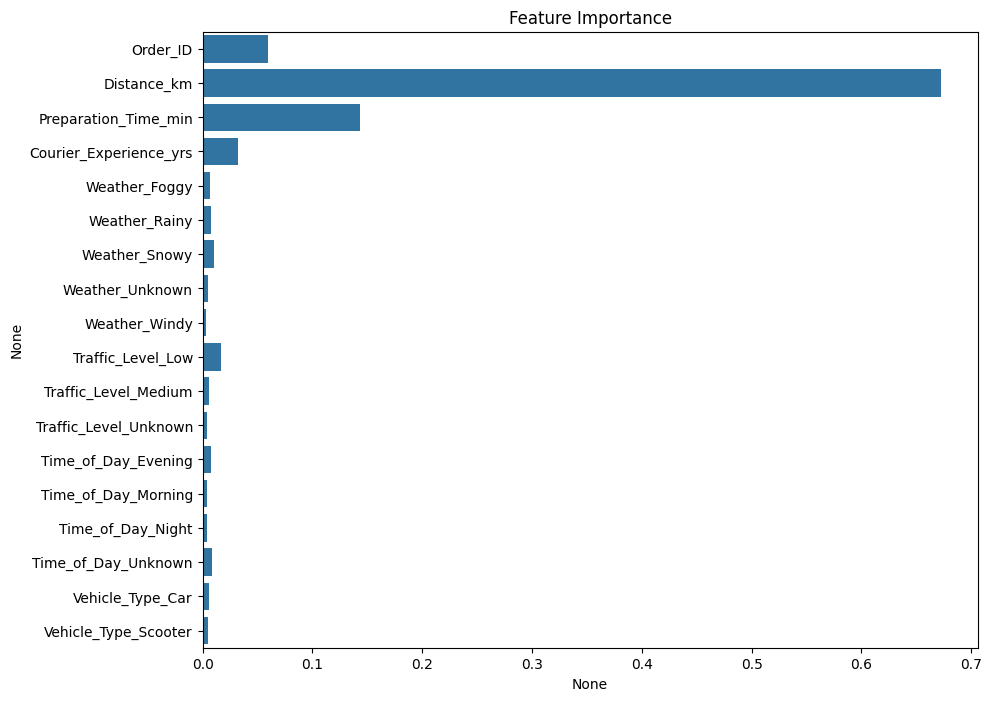

In [166]:
# Extract feature importance values
importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))
features = X.columns

# Plot feature importance
plt.figure(figsize=(10,8))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

In [167]:
# Prediction function used by the GUI
def predict_delivery_time(distance, weather, traffic, time_of_day, vehicle, prep_time, experience):
    sample = pd.DataFrame([{
        "Distance_km": distance,
        "Weather": weather,
        "Traffic_Level": traffic,
        "Time_of_Day": time_of_day,
        "Vehicle_Type": vehicle,
        "Preparation_Time_min": prep_time,
        "Courier_Experience_yrs": experience
    }])

     # One-hot encode the sample
    sample_encoded = pd.get_dummies(sample)

    # Align encoded columns with training data
    sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

    # Predict using tuned Random Forest model
    return best_model.predict(sample_encoded)[0]

In [168]:
# Dropdown options for GUI
weather_options = ["Clear", "Rainy", "Snowy", "Foggy", "Windy", "Unknown"]
traffic_options = ["Low", "Medium", "High", "Unknown"]
time_options = ["Morning", "Afternoon", "Evening", "Night", "Unknown"]
vehicle_options = ["Bike", "Scooter", "Car"]

# Build Gradio interface
gui = gr.Interface(
    fn=predict_delivery_time,
    inputs=[
        gr.Number(label="Distance (km)"),
        gr.Dropdown(weather_options, label="Weather"),
        gr.Dropdown(traffic_options, label="Traffic Level"),
        gr.Dropdown(time_options, label="Time of Day"),
        gr.Dropdown(vehicle_options, label="Vehicle Type"),
        gr.Number(label="Preparation Time (min)"),
        gr.Number(label="Courier Experience (years)")
    ],
    outputs=gr.Number(label="Predicted Delivery Time (min)"),
    title="Food Delivery Time Predictor",
    description="Enter delivery details to estimate delivery time using Random Forest."
)

# Launch GUI
gui.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dc8295392f4a888594.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Distance was the strongest predictor for delivery time. Other factors are preparation_time_min, Traffic_Level, and Weather.

High MAE and RMSE shows that Linear Regression is not suitable for this dataset. Dataset deals with nonlinear interactions such as weather, traffic and vehicles. Linear Regression cannont model these effectively. Chose to go with Non Linear Regression and GridSearchCV instead

Random Forest signifiacantly improves results lower MAE and RMSE, better handling of categorical variables and more robust abd better generalization

grid search improved depth control, number of tress and split treshold

Random Forest best for machine learning predicting food delivery times. It captures more of the complex non linear relationships.